In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
print(df.shape)
print(df.info())

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [5]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [18]:
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


### **Feature Engineering**

In [21]:
df['SepalArea'] = df['SepalLengthCm'] * df['SepalWidthCm']
df['PetalArea'] = df['PetalLengthCm'] * df['PetalWidthCm']

df['PetalSepalRatio'] = (df['PetalArea']/df['SepalArea'])
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,SepalArea,PetalArea,PetalSepalRatio
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,17.806533,5.793133,0.314745
std,0.828066,0.433594,1.764420,0.763161,3.368693,4.713499,0.236010
min,4.300000,2.000000,1.000000,0.100000,10.000000,0.110000,0.007036
25%,5.100000,2.800000,1.600000,0.300000,15.645000,0.420000,0.023640
50%,5.800000,3.000000,4.350000,1.300000,17.660000,5.615000,0.336696
75%,6.400000,3.300000,5.100000,1.800000,20.325000,9.690000,0.515812
max,7.900000,4.400000,6.900000,2.500000,30.020000,15.870000,0.792707


In [22]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,SepalArea,PetalArea,PetalSepalRatio
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,17.806533,5.793133,0.314745
std,0.828066,0.433594,1.764420,0.763161,3.368693,4.713499,0.236010
min,4.300000,2.000000,1.000000,0.100000,10.000000,0.110000,0.007036
25%,5.100000,2.800000,1.600000,0.300000,15.645000,0.420000,0.023640
50%,5.800000,3.000000,4.350000,1.300000,17.660000,5.615000,0.336696
75%,6.400000,3.300000,5.100000,1.800000,20.325000,9.690000,0.515812
max,7.900000,4.400000,6.900000,2.500000,30.020000,15.870000,0.792707


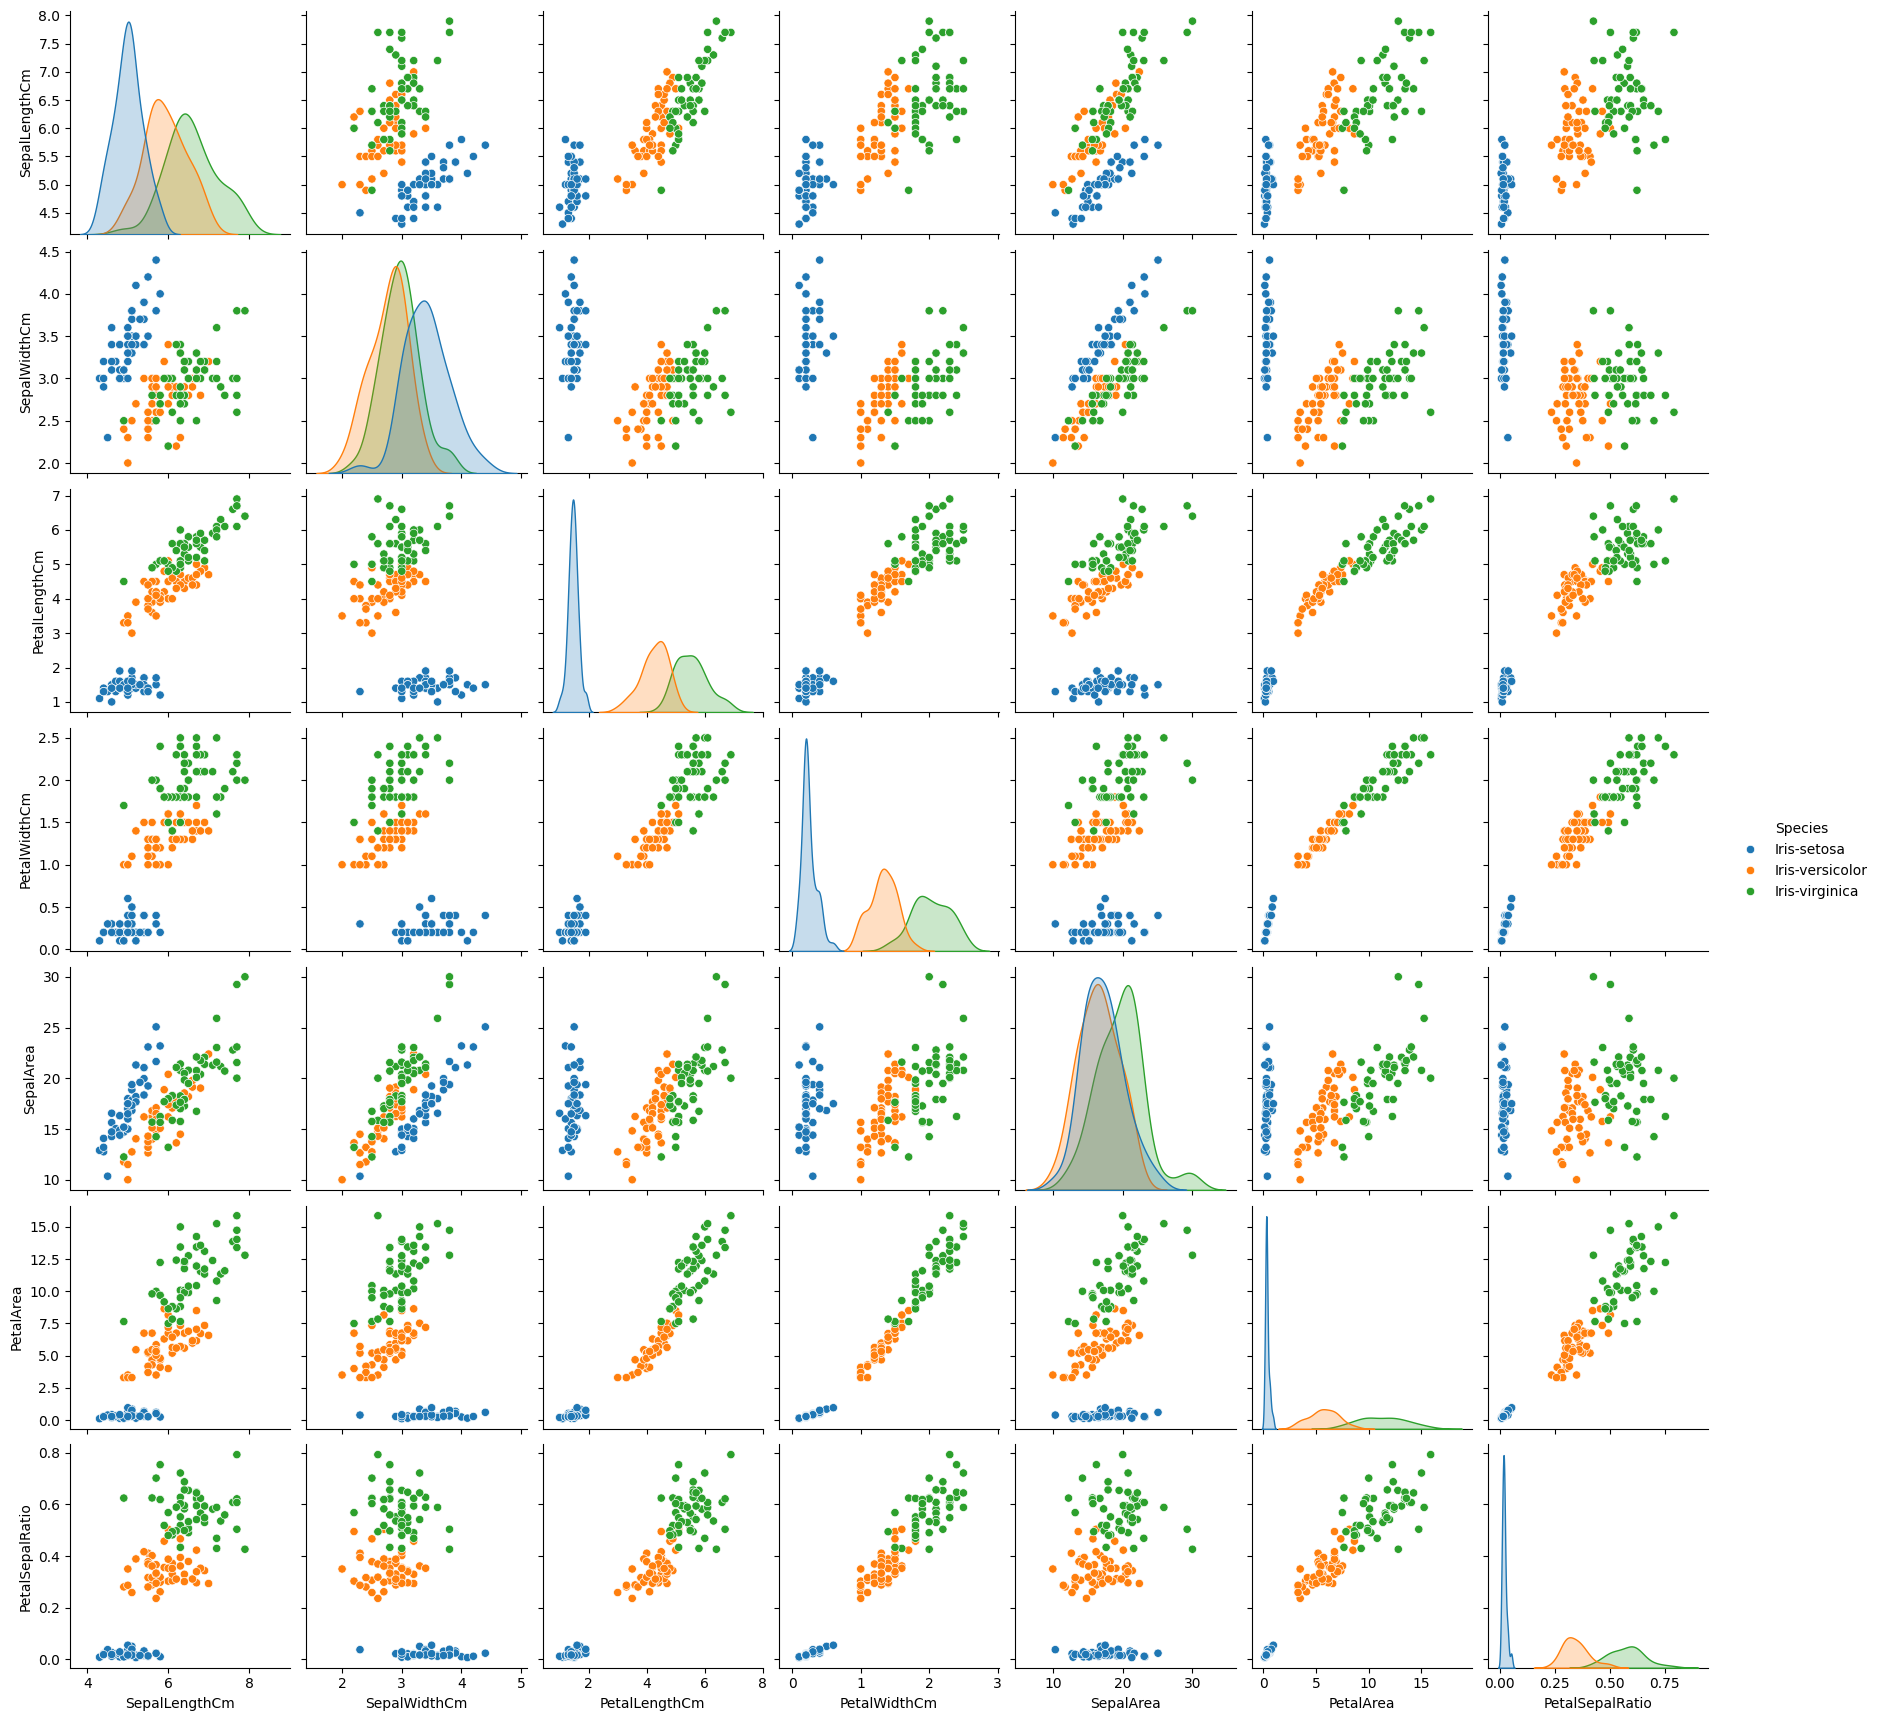

In [23]:
sns.pairplot(df, hue="Species")
plt.show()

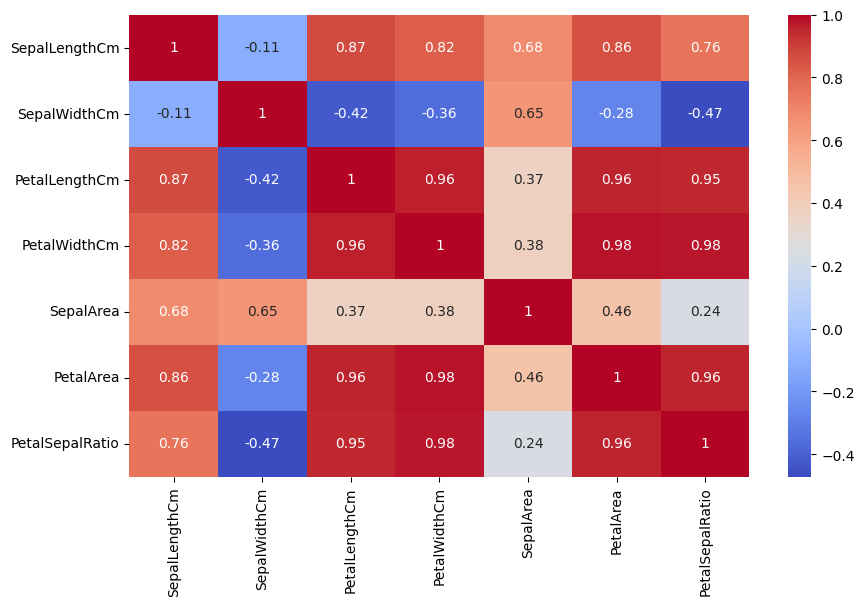

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.drop("Species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [26]:
X = df.drop("Species", axis=1)
y = df["Species"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### **Train Test Split**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **Train Multiple Model**

In [28]:
models = {
    "Logistic Regression":
    LogisticRegression(max_iter=500),

    "KNN":
    KNeighborsClassifier(),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(),

    "SVM":
    SVC(probability=True),

    "Gradient Boosting":
    GradientBoostingClassifier()
}

In [29]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy = accuracy_score( y_test, pred)

    results[name] = accuracy

    print(name, ":", accuracy)

Logistic Regression : 0.9666666666666667
KNN : 1.0
Decision Tree : 0.9
Random Forest : 0.9333333333333333
SVM : 0.9666666666666667
Gradient Boosting : 0.9333333333333333


In [32]:
best_model_name = max(
    results,
    key=results.get
)
print("Best model among all of this is: ",best_model_name)

Best model among all of this is:  KNN


In [34]:
param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[3,5,7,None],
    "min_samples_split":[2,5,10]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [36]:
best_model  = grid.best_estimator_
best_model


RandomForestClassifier(max_depth=3, random_state=42)

### **Cross Validation**

In [37]:
scores = cross_val_score(
    best_model,
    X_scaled,
    y,
    cv=10
)

print(scores)
print(scores.mean())

[1.         0.93333333 1.         0.93333333 0.93333333 0.93333333
 0.86666667 1.         1.         1.        ]
0.96


In [39]:
best_model.fit(
    X_train,
    y_train
)

y_pred = best_model.predict(
    X_test
)
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [40]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



### **confusion Matrix**

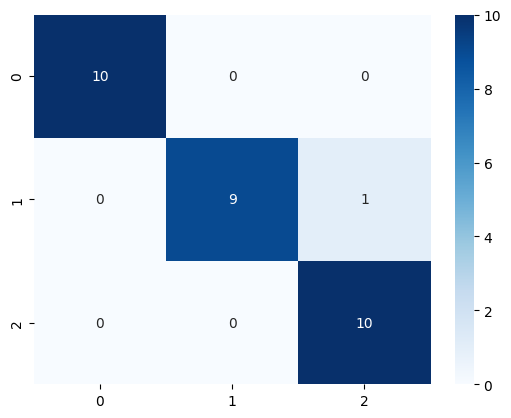

In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

In [42]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":
    best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

           Feature  Importance
5        PetalArea    0.280573
6  PetalSepalRatio    0.274290
2    PetalLengthCm    0.206814
3     PetalWidthCm    0.169163
0    SepalLengthCm    0.044980
1     SepalWidthCm    0.015547
4        SepalArea    0.008633


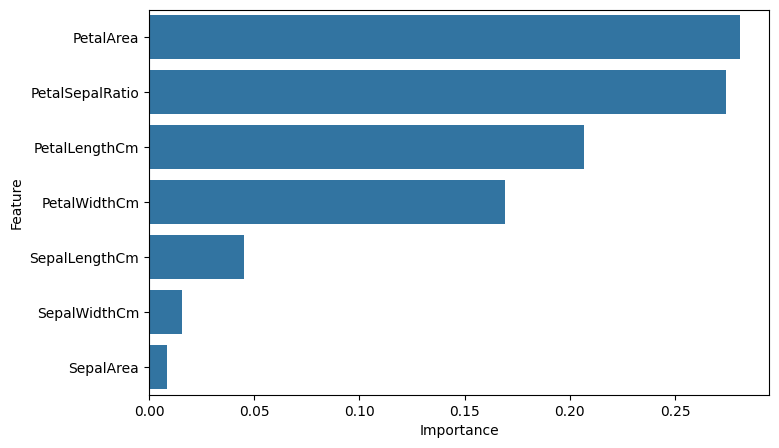

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.show()

In [44]:
pickle.dump(
    best_model,
    open("iris_model.pkl","wb")
)

pickle.dump(
    scaler,
    open("iris_scaler.pkl","wb")
)

In [49]:
sample = np.array([[5.1,3.5,1.4,0.2,17.85,0.28,0.0157]])
sample_scaled = scaler.transform(sample)
print(sample_scaled)

[[-0.90068117  1.03205722 -1.3412724  -1.31297673  0.01294635 -1.17356615
  -1.27133148]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [50]:
prediction = best_model.predict(
    sample_scaled
)
print(prediction)

['Iris-setosa']
